In [229]:
# Importing libraries

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import ezodf
import re

In [230]:
# Listing transaction datasets across 2020-2024

transaction_datasets = [
    '../data/raw/transactions_2020.csv',
    '../data/raw/transactions_2021.csv',
    '../data/raw/transactions_2022.csv',
    '../data/raw/transactions_2023.csv',
    '../data/raw/transactions_2024.csv',
]

In [231]:
# Defining column names for transaction datasets

transaction_headers = [
    'Transaction Unique Identifier',
    'Price',
    'Date of Transfer',
    'Postcode',
    'Property Type',
    'Old/New',
    'Duration',
    'PAON',
    'SAON',
    'Street',
    'Locality',
    'Town/City',
    'District',
    'County',
    'PPD Category Type',
    'Record Status'
]

In [232]:
# Reading the property transaction datasets into a list

transaction_list = [pd.read_csv(dataset, header=None, names=transaction_headers) for dataset in transaction_datasets]

In [233]:
# Merging all datasets together into one dataframe

df_transactions = pd.concat(transaction_list, axis=0, ignore_index=True)

df_transactions

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,PAON,SAON,Street,Locality,Town/City,District,County,PPD Category Type,Record Status
0,{AC07BBCF-E34C-0445-E053-6C04A8C01E31},150000,2020-06-12 00:00,WA7 5BU,D,N,F,12,NaN,ECCLESTON DRIVE,NaN,RUNCORN,HALTON,HALTON,A,A
1,{AC07BBCF-E34D-0445-E053-6C04A8C01E31},375000,2020-03-27 00:00,SK9 4ET,D,N,F,26,NaN,STANNEYLANDS DRIVE,NaN,WILMSLOW,CHESHIRE EAST,CHESHIRE EAST,A,A
2,{AC07BBCF-E34E-0445-E053-6C04A8C01E31},140000,2020-03-04 00:00,CW9 8BP,T,N,F,7,NaN,ADLINGTON DRIVE,NaN,NORTHWICH,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,A,A
3,{AC07BBCF-E34F-0445-E053-6C04A8C01E31},95000,2020-04-30 00:00,WA8 8UT,S,N,F,410,NaN,HALE ROAD,NaN,WIDNES,HALTON,HALTON,A,A
4,{AC07BBCF-E350-0445-E053-6C04A8C01E31},170000,2020-04-30 00:00,WA5 3LZ,S,N,F,2,NaN,CLARENCE AVENUE,GREAT SANKEY,WARRINGTON,WARRINGTON,WARRINGTON,A,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5022271,{1EAE3DF7-2F7E-9EB1-E063-4704A8C09D02},249500,2024-07-08 00:00,TA20 2QR,S,N,F,29,NaN,LINKHAY ORCHARD,SOUTH CHARD,CHARD,SOMERSET,SOMERSET,A,A
5022272,{1EAE3DF7-2F7F-9EB1-E063-4704A8C09D02},345000,2024-07-04 00:00,BA5 1UG,T,N,F,5,NaN,SOUTHOVER,NaN,WELLS,SOMERSET,SOMERSET,A,A
5022273,{1EAE3DF7-2F80-9EB1-E063-4704A8C09D02},165000,2024-07-01 00:00,TA18 8DA,F,N,L,CHRISTCHURCH COURT,FLAT 4,SOUTH STREET,NaN,CREWKERNE,SOMERSET,SOMERSET,A,A
5022274,{1EAE3DF7-2F81-9EB1-E063-4704A8C09D02},165000,2024-07-05 00:00,TA18 8ES,T,N,F,8,NaN,HERMITAGE STREET,NaN,CREWKERNE,SOMERSET,SOMERSET,A,A


In [234]:
# Inspecting data types in df_transactions

df_transactions.dtypes

Transaction Unique Identifier    object
Price                             int64
Date of Transfer                 object
Postcode                         object
Property Type                    object
Old/New                          object
Duration                         object
PAON                             object
SAON                             object
Street                           object
Locality                         object
Town/City                        object
District                         object
County                           object
PPD Category Type                object
Record Status                    object
dtype: object

In [235]:
# Reading the Ofsted school inspection dataset and converting it into a Pandas DataFrame

sheet_schools = ezodf.opendoc('../data/raw/schools.ods').sheets[2] # Selecting the third sheet which contains the data

rows_schools = list(sheet_schools.rows())
headers_schools = [cell.value for cell in rows_schools[2]] # Obtaining column names from row index 2
records_schools = rows_schools[3:] # Obtaining data records from row index 3 onwards

data_schools = []
for record in records_schools:
    values = [cell.value for cell in record] # Extracting values to append into the list
    data_schools.append(values)

df_schools = pd.DataFrame(data_schools, columns=headers_schools) # Converting the list into a Pandas DataFrame

df_schools

,URN,Name,Five-Year Ofsted Inspection Data publish date,Publication type,Remit,As at date,Published date,Government office region,Local authority area,Constituency,...,Category of concern,Effectiveness of leadership and management,Quality of education,Personal development,Behaviour and attitudes,Safeguarding is effective?,Early years provision (where applicable),Sixth form provision (where applicable),Does the inspection relate to the URN of the current school?,None
0,100000.0,The Aldgate School,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2024-07-11T00:00:00,London,City of London,Cities of London and Westminster,...,None,1.0,1.0,1.0,1.0,Yes,2.0,9.0,Yes,None
1,100005.0,Thomas Coram Centre,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2014-07-02T00:00:00,London,Camden,Holborn and St Pancras,...,None,1.0,9.0,9.0,9.0,9.0,9.0,9.0,Yes,None
2,100006.0,Heath School,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2024-07-04T00:00:00,London,Camden,Hampstead and Highgate,...,None,1.0,2.0,1.0,1.0,Yes,9.0,9.0,Yes,None
3,100007.0,Camden Primary Pupil Referral Unit,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2015-05-05T00:00:00,London,Camden,Holborn and St Pancras,...,None,2.0,9.0,9.0,9.0,9.0,9.0,9.0,Yes,None
4,100008.0,Argyle Primary School,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2022-11-17T00:00:00,London,Camden,Holborn and St Pancras,...,None,2.0,2.0,1.0,2.0,Yes,2.0,9.0,Yes,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131924,148026.0,"St Antony's Roman Catholic School, a Voluntary...",2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2019-11-28T00:00:00,North West,Trafford,Stretford and Urmston,...,SWK,4.0,3.0,2.0,2.0,Yes,9.0,9.0,No,None
131925,148036.0,Gloucester Academy,2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2018-05-29T00:00:00,South West,Gloucestershire,Gloucester,...,SM,4.0,9.0,9.0,9.0,No,9.0,3.0,No,None
131926,148039.0,Northbrook Primary Academy,2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2019-11-18T00:00:00,North West,Lancashire,South Ribble,...,SM,4.0,4.0,4.0,4.0,Yes,3.0,9.0,No,None
131927,148050.0,"St Monica's RC High School, a Voluntary Academy",2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2019-12-19T00:00:00,North West,Bury,Bury South,...,None,3.0,3.0,3.0,3.0,Yes,9.0,9.0,No,None


In [236]:
# Inspecting data types in df_schools

df_schools.dtypes

URN                                                             float64
Name                                                             object
Five-Year Ofsted Inspection Data publish date                    object
Publication type                                                 object
Remit                                                            object
As at date                                                       object
Published date                                                   object
Government office region                                         object
Local authority area                                             object
Constituency                                                     object
Postcode                                                         object
Provider type                                                    object
Provision type                                                   object
Phase                                                           

In [237]:
# Reading the ONS Postcode Directory dataset

df_onspd = pd.read_csv('../data/raw/onspd.csv')

df_onspd

,pcd7,pcd8,pcds,dointr,doterm,cty25cd,ced25cd,lad25cd,wd25cd,parncp25cd,...,lep21cd1,lep21cd2,pfa23cd,imd20ind,cal24cd,icb23cd,oa21cd,lsoa21cd,msoa21cd,ruc21ind
0,M1 1AA,M1 1AA,M1 1AA,199507,200904.0,E99999999,E99999999,E08000003,E05011376,E43000157,...,E37000015,NaN,E23000005,13409,E56000032,E54000057,E00180796,E01033651,E02006902,UN1
1,M1 1AD,M1 1AD,M1 1AD,200303,NaN,E99999999,E99999999,E08000003,E05011361,E43000157,...,E37000015,NaN,E23000005,12008,E56000032,E54000057,E00175827,E01033658,E02006902,UN1
2,M1 1AE,M1 1AE,M1 1AE,200501,NaN,E99999999,E99999999,E08000003,E05011376,E43000157,...,E37000015,NaN,E23000005,10952,E56000032,E54000057,E00176052,E01034129,E02006912,UN1
3,M1 1AF,M1 1AF,M1 1AF,200506,NaN,E99999999,E99999999,E08000003,E05011376,E43000157,...,E37000015,NaN,E23000005,8141,E56000032,E54000057,E00175961,E01033653,E02006912,UN1
4,M1 1AG,M1 1AG,M1 1AG,201003,202501.0,E99999999,E99999999,E08000003,E05011376,E43000157,...,E37000015,NaN,E23000005,10952,E56000032,E54000057,E00175823,E01034129,E02006912,UN1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59993,M99 1ZU,M99 1ZU,M99 1ZU,200701,NaN,E99999999,E99999999,E08000003,E05011376,E43000157,...,E37000015,NaN,E23000005,10952,E56000032,E54000057,E00175823,E01034129,E02006912,UN1
59994,M99 1ZW,M99 1ZW,M99 1ZW,200405,NaN,E99999999,E99999999,E08000003,E05011361,E43000157,...,E37000015,NaN,E23000005,12008,E56000032,E54000057,E00175827,E01033658,E02006902,UN1
59995,M99 2BE,M99 2BE,M99 2BE,200604,NaN,E99999999,E99999999,E08000003,E05011376,E43000157,...,E37000015,NaN,E23000005,10952,E56000032,E54000057,E00175823,E01034129,E02006912,UN1
59996,M99 2BS,M99 2BS,M99 2BS,200604,NaN,E99999999,E99999999,E08000003,E05011376,E43000157,...,E37000015,NaN,E23000005,10952,E56000032,E54000057,E00175823,E01034129,E02006912,UN1


In [238]:
# Inspecting data types in df_onspd

df_onspd.dtypes

pcd7           object
pcd8           object
pcds           object
dointr          int64
doterm        float64
cty25cd        object
ced25cd        object
lad25cd        object
wd25cd         object
parncp25cd     object
usrtypind       int64
east1m        float64
north1m       float64
gridind         int64
hlth19cd       object
nhser24cd      object
ctry25cd       object
rgn25cd        object
ssr95cd        object
pcon24cd       object
eer20cd        object
educ23cd       object
ttwa15cd       object
pco19cd        object
itl25cd        object
wdstl05cd      object
oa01cd         object
wdcas03cd      object
npark16cd      object
lsoa01cd       object
msoa01cd       object
ruc01ind       object
oac01ind       object
oa11cd         object
lsoa11cd       object
msoa11cd       object
wz11cd         object
sicbl24cd      object
bua24cd        object
ruc11ind       object
oac11ind       object
lat           float64
long          float64
lep21cd1       object
lep21cd2      float64
pfa23cd   

In [239]:
# Reading the IMD dataset

df_imd = pd.read_excel('../data/raw/imd.xlsx', sheet_name='IMD25')

df_imd

,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA
0,E01000001,City of London 001A,E09000001,City of London,26525,8
1,E01000002,City of London 001B,E09000001,City of London,31203,10
2,E01000003,City of London 001C,E09000001,City of London,25913,8
3,E01000005,City of London 001E,E09000001,City of London,14807,5
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,10917,4
...,...,...,...,...,...,...
33750,E01035758,Vale of White Horse 014H,E07000180,Vale of White Horse,27536,9
33751,E01035759,Vale of White Horse 015G,E07000180,Vale of White Horse,27902,9
33752,E01035760,Vale of White Horse 015H,E07000180,Vale of White Horse,27532,9
33753,E01035761,Vale of White Horse 015I,E07000180,Vale of White Horse,28981,9


In [240]:
# Inspecting data types in df_transactions

df_imd.dtypes

LSOA code (2021)                                                                    object
LSOA name (2021)                                                                    object
Local Authority District code (2024)                                                object
Local Authority District name (2024)                                                object
Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)                  int64
Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA     int64
dtype: object

In [241]:
# Function to standardise postcode formats

def standardise_postcode(df, col):
    df[col] = (df[col].astype(str).str.upper().str.strip()) # Ensures that all postcodes are strings, all uppercase, and does not have unnecessary whitespace
    df = df[df[col].notna()] # Removes NaN postcodes
    df = df[df[col] != ''] # Removes empty postcodes

    postcode_regex = r'^[A-Z]{1,2}[0-9][0-9A-Z]?\s?[0-9][A-Z]{2}' # Specifies the standard format for UK postcodes
    df = df[df[col].str.match(postcode_regex)]

    return df

In [242]:
# Standardising postcodes in df_transactions

df_transactions_standardised = standardise_postcode(df_transactions, 'Postcode')

df_transactions_standardised

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,PAON,SAON,Street,Locality,Town/City,District,County,PPD Category Type,Record Status
0,{AC07BBCF-E34C-0445-E053-6C04A8C01E31},150000,2020-06-12 00:00,WA7 5BU,D,N,F,12,NaN,ECCLESTON DRIVE,NaN,RUNCORN,HALTON,HALTON,A,A
1,{AC07BBCF-E34D-0445-E053-6C04A8C01E31},375000,2020-03-27 00:00,SK9 4ET,D,N,F,26,NaN,STANNEYLANDS DRIVE,NaN,WILMSLOW,CHESHIRE EAST,CHESHIRE EAST,A,A
2,{AC07BBCF-E34E-0445-E053-6C04A8C01E31},140000,2020-03-04 00:00,CW9 8BP,T,N,F,7,NaN,ADLINGTON DRIVE,NaN,NORTHWICH,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,A,A
3,{AC07BBCF-E34F-0445-E053-6C04A8C01E31},95000,2020-04-30 00:00,WA8 8UT,S,N,F,410,NaN,HALE ROAD,NaN,WIDNES,HALTON,HALTON,A,A
4,{AC07BBCF-E350-0445-E053-6C04A8C01E31},170000,2020-04-30 00:00,WA5 3LZ,S,N,F,2,NaN,CLARENCE AVENUE,GREAT SANKEY,WARRINGTON,WARRINGTON,WARRINGTON,A,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5022271,{1EAE3DF7-2F7E-9EB1-E063-4704A8C09D02},249500,2024-07-08 00:00,TA20 2QR,S,N,F,29,NaN,LINKHAY ORCHARD,SOUTH CHARD,CHARD,SOMERSET,SOMERSET,A,A
5022272,{1EAE3DF7-2F7F-9EB1-E063-4704A8C09D02},345000,2024-07-04 00:00,BA5 1UG,T,N,F,5,NaN,SOUTHOVER,NaN,WELLS,SOMERSET,SOMERSET,A,A
5022273,{1EAE3DF7-2F80-9EB1-E063-4704A8C09D02},165000,2024-07-01 00:00,TA18 8DA,F,N,L,CHRISTCHURCH COURT,FLAT 4,SOUTH STREET,NaN,CREWKERNE,SOMERSET,SOMERSET,A,A
5022274,{1EAE3DF7-2F81-9EB1-E063-4704A8C09D02},165000,2024-07-05 00:00,TA18 8ES,T,N,F,8,NaN,HERMITAGE STREET,NaN,CREWKERNE,SOMERSET,SOMERSET,A,A


In [243]:
# Standardising postcodes in df_schools

df_schools_standardised = standardise_postcode(df_schools, 'Postcode')

df_schools_standardised

,URN,Name,Five-Year Ofsted Inspection Data publish date,Publication type,Remit,As at date,Published date,Government office region,Local authority area,Constituency,...,Category of concern,Effectiveness of leadership and management,Quality of education,Personal development,Behaviour and attitudes,Safeguarding is effective?,Early years provision (where applicable),Sixth form provision (where applicable),Does the inspection relate to the URN of the current school?,None
0,100000.0,The Aldgate School,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2024-07-11T00:00:00,London,City of London,Cities of London and Westminster,...,None,1.0,1.0,1.0,1.0,Yes,2.0,9.0,Yes,None
1,100005.0,Thomas Coram Centre,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2014-07-02T00:00:00,London,Camden,Holborn and St Pancras,...,None,1.0,9.0,9.0,9.0,9.0,9.0,9.0,Yes,None
2,100006.0,Heath School,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2024-07-04T00:00:00,London,Camden,Hampstead and Highgate,...,None,1.0,2.0,1.0,1.0,Yes,9.0,9.0,Yes,None
3,100007.0,Camden Primary Pupil Referral Unit,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2015-05-05T00:00:00,London,Camden,Holborn and St Pancras,...,None,2.0,9.0,9.0,9.0,9.0,9.0,9.0,Yes,None
4,100008.0,Argyle Primary School,2025-04-02T00:00:00,OS,State-funded schools,2024-12-31T00:00:00,2022-11-17T00:00:00,London,Camden,Holborn and St Pancras,...,None,2.0,2.0,1.0,2.0,Yes,2.0,9.0,Yes,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131923,148024.0,The New Forest Church of England Primary School,2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2018-09-12T00:00:00,South West,Wiltshire,Salisbury,...,None,3.0,9.0,9.0,9.0,Yes,3.0,9.0,No,None
131924,148026.0,"St Antony's Roman Catholic School, a Voluntary...",2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2019-11-28T00:00:00,North West,Trafford,Stretford and Urmston,...,SWK,4.0,3.0,2.0,2.0,Yes,9.0,9.0,No,None
131925,148036.0,Gloucester Academy,2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2018-05-29T00:00:00,South West,Gloucestershire,Gloucester,...,SM,4.0,9.0,9.0,9.0,No,9.0,3.0,No,None
131926,148039.0,Northbrook Primary Academy,2024-12-03T00:00:00,OS,State-funded schools,2020-08-31T00:00:00,2019-11-18T00:00:00,North West,Lancashire,South Ribble,...,SM,4.0,4.0,4.0,4.0,Yes,3.0,9.0,No,None


In [244]:
# Defines important columns in each dataset

transaction_cols = [
    'Transaction Unique Identifier',
    'Price',
    'Date of Transfer',
    'Postcode',
    'Property Type',
    'Old/New',
    'Duration'
]

school_cols = [
    'URN',
    'As at date',
    'Postcode',
    'Phase',
    'Overall effectiveness'
]

onspd_cols = [
    'pcds',
    'lad25cd',
    'lat',
    'long',
    'lsoa21cd'
]

imd_cols = [
    'LSOA code (2021)',
    'Local Authority District code (2024)',
    'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)',
    'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA'
]

In [245]:
# Filtering important columns in df_transactions_standardised

df_transactions_filtered = df_transactions_standardised[transaction_cols]

df_transactions_filtered

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration
0,{AC07BBCF-E34C-0445-E053-6C04A8C01E31},150000,2020-06-12 00:00,WA7 5BU,D,N,F
1,{AC07BBCF-E34D-0445-E053-6C04A8C01E31},375000,2020-03-27 00:00,SK9 4ET,D,N,F
2,{AC07BBCF-E34E-0445-E053-6C04A8C01E31},140000,2020-03-04 00:00,CW9 8BP,T,N,F
3,{AC07BBCF-E34F-0445-E053-6C04A8C01E31},95000,2020-04-30 00:00,WA8 8UT,S,N,F
4,{AC07BBCF-E350-0445-E053-6C04A8C01E31},170000,2020-04-30 00:00,WA5 3LZ,S,N,F
...,...,...,...,...,...,...,...
5022271,{1EAE3DF7-2F7E-9EB1-E063-4704A8C09D02},249500,2024-07-08 00:00,TA20 2QR,S,N,F
5022272,{1EAE3DF7-2F7F-9EB1-E063-4704A8C09D02},345000,2024-07-04 00:00,BA5 1UG,T,N,F
5022273,{1EAE3DF7-2F80-9EB1-E063-4704A8C09D02},165000,2024-07-01 00:00,TA18 8DA,F,N,L
5022274,{1EAE3DF7-2F81-9EB1-E063-4704A8C09D02},165000,2024-07-05 00:00,TA18 8ES,T,N,F


In [246]:
# Filtering important columns in df_schools_standardised

df_schools_filtered = df_schools_standardised[school_cols]

df_schools_filtered

,URN,As at date,Postcode,Phase,Overall effectiveness
0,100000.0,2024-12-31T00:00:00,EC3A 5DE,Primary,1.0
1,100005.0,2024-12-31T00:00:00,WC1N 2NY,Nursery,1.0
2,100006.0,2024-12-31T00:00:00,NW3 2NY,PRU,2.0
3,100007.0,2024-12-31T00:00:00,NW1 3EX,PRU,2.0
4,100008.0,2024-12-31T00:00:00,WC1H 9EG,Primary,2.0
...,...,...,...,...,...
131923,148024.0,2020-08-31T00:00:00,SP5 2BY,Primary,3.0
131924,148026.0,2020-08-31T00:00:00,M41 9PD,Secondary,4.0
131925,148036.0,2020-08-31T00:00:00,GL4 6RN,Secondary,4.0
131926,148039.0,2020-08-31T00:00:00,PR25 2GB,Primary,4.0


In [247]:
# Filtering important columns in df_onspd

df_onspd_filtered = df_onspd[onspd_cols]

df_onspd_filtered

,pcds,lad25cd,lat,long,lsoa21cd
0,M1 1AA,E08000003,53.487378,-2.227194,E01033651
1,M1 1AD,E08000003,53.483829,-2.244852,E01033658
2,M1 1AE,E08000003,53.483487,-2.231182,E01034129
3,M1 1AF,E08000003,53.480563,-2.237148,E01033653
4,M1 1AG,E08000003,53.483298,-2.231452,E01034129
...,...,...,...,...,...
59993,M99 1ZU,E08000003,53.483009,-2.232264,E01034129
59994,M99 1ZW,E08000003,53.487374,-2.242687,E01033658
59995,M99 2BE,E08000003,53.483009,-2.232264,E01034129
59996,M99 2BS,E08000003,53.483009,-2.232264,E01034129


In [248]:
# Filtering important columns in df_imd

df_imd_filtered = df_imd[imd_cols]

df_imd_filtered

,LSOA code (2021),Local Authority District code (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA
0,E01000001,E09000001,26525,8
1,E01000002,E09000001,31203,10
2,E01000003,E09000001,25913,8
3,E01000005,E09000001,14807,5
4,E01000006,E09000002,10917,4
...,...,...,...,...
33750,E01035758,E07000180,27536,9
33751,E01035759,E07000180,27902,9
33752,E01035760,E07000180,27532,9
33753,E01035761,E07000180,28981,9


In [249]:
# Merging df_onspd_filtered into df_transactions_standardised

df_transactions_merged = df_transactions_filtered.merge(df_onspd_filtered, left_on='Postcode', right_on='pcds', how='left')

df_transactions_merged

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,pcds,lad25cd,lat,long,lsoa21cd
0,{AC07BBCF-E34C-0445-E053-6C04A8C01E31},150000,2020-06-12 00:00,WA7 5BU,D,N,F,NaN,NaN,NaN,NaN,NaN
1,{AC07BBCF-E34D-0445-E053-6C04A8C01E31},375000,2020-03-27 00:00,SK9 4ET,D,N,F,NaN,NaN,NaN,NaN,NaN
2,{AC07BBCF-E34E-0445-E053-6C04A8C01E31},140000,2020-03-04 00:00,CW9 8BP,T,N,F,NaN,NaN,NaN,NaN,NaN
3,{AC07BBCF-E34F-0445-E053-6C04A8C01E31},95000,2020-04-30 00:00,WA8 8UT,S,N,F,NaN,NaN,NaN,NaN,NaN
4,{AC07BBCF-E350-0445-E053-6C04A8C01E31},170000,2020-04-30 00:00,WA5 3LZ,S,N,F,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
5007096,{1EAE3DF7-2F7E-9EB1-E063-4704A8C09D02},249500,2024-07-08 00:00,TA20 2QR,S,N,F,NaN,NaN,NaN,NaN,NaN
5007097,{1EAE3DF7-2F7F-9EB1-E063-4704A8C09D02},345000,2024-07-04 00:00,BA5 1UG,T,N,F,NaN,NaN,NaN,NaN,NaN
5007098,{1EAE3DF7-2F80-9EB1-E063-4704A8C09D02},165000,2024-07-01 00:00,TA18 8DA,F,N,L,NaN,NaN,NaN,NaN,NaN
5007099,{1EAE3DF7-2F81-9EB1-E063-4704A8C09D02},165000,2024-07-05 00:00,TA18 8ES,T,N,F,NaN,NaN,NaN,NaN,NaN


In [250]:
# Merging df_onspd_filtered into df_schools_standardised

df_schools_merged = df_schools_filtered.merge(df_onspd_filtered, left_on='Postcode', right_on='pcds', how='left')

df_schools_merged

,URN,As at date,Postcode,Phase,Overall effectiveness,pcds,lad25cd,lat,long,lsoa21cd
0,100000.0,2024-12-31T00:00:00,EC3A 5DE,Primary,1.0,NaN,NaN,NaN,NaN,NaN
1,100005.0,2024-12-31T00:00:00,WC1N 2NY,Nursery,1.0,NaN,NaN,NaN,NaN,NaN
2,100006.0,2024-12-31T00:00:00,NW3 2NY,PRU,2.0,NaN,NaN,NaN,NaN,NaN
3,100007.0,2024-12-31T00:00:00,NW1 3EX,PRU,2.0,NaN,NaN,NaN,NaN,NaN
4,100008.0,2024-12-31T00:00:00,WC1H 9EG,Primary,2.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
131923,148024.0,2020-08-31T00:00:00,SP5 2BY,Primary,3.0,NaN,NaN,NaN,NaN,NaN
131924,148026.0,2020-08-31T00:00:00,M41 9PD,Secondary,4.0,M41 9PD,E08000009,53.449131,-2.334575,E01006156
131925,148036.0,2020-08-31T00:00:00,GL4 6RN,Secondary,4.0,NaN,NaN,NaN,NaN,NaN
131926,148039.0,2020-08-31T00:00:00,PR25 2GB,Primary,4.0,NaN,NaN,NaN,NaN,NaN


In [251]:
# Confirming df_transactions_merged merge success by finding the number of records with an M-postcode (records with a non-null 'pcds' value)

df_transactions_merged['pcds'].isna().value_counts()

pcds
True     4904338
False     102763
Name: count, dtype: int64

In [252]:
# Confirming df_schools_merged merge success by finding the number of records with an M-postcode (records with a non-null 'pcds' value)

df_schools_merged['pcds'].isna().value_counts()

pcds
True     129155
False      2773
Name: count, dtype: int64

In [253]:
# Filtering Manchester-based records in df_transactions_merged

df_transactions_manchester = df_transactions_merged[df_transactions_merged['lad25cd'] == 'E08000003']

df_transactions_manchester

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,pcds,lad25cd,lat,long,lsoa21cd
748,{BC8936BB-A9A5-0E2C-E053-6C04A8C0DBF4},195000,2020-11-27 00:00,M40 2SZ,T,N,F,M40 2SZ,E08000003,53.496830,-2.188129,E01005261
1332,{BC8936BB-BA17-0E2C-E053-6C04A8C0DBF4},193000,2020-12-21 00:00,M3 4AZ,F,N,L,M3 4AZ,E08000003,53.475279,-2.262702,E01033673
1334,{BC8936BB-BA19-0E2C-E053-6C04A8C0DBF4},283500,2020-12-02 00:00,M21 9HP,F,N,L,M21 9HP,E08000003,53.441642,-2.279734,E01005150
2490,{BC8936BB-A73B-0E2C-E053-6C04A8C0DBF4},213500,2020-12-18 00:00,M20 3FF,T,N,F,M20 3FF,E08000003,53.434101,-2.232872,E01005274
2496,{BC8936BB-A743-0E2C-E053-6C04A8C0DBF4},335000,2020-12-18 00:00,M20 5PW,S,N,L,M20 5PW,E08000003,53.403338,-2.221227,E01005171
...,...,...,...,...,...,...,...,...,...,...,...,...
5006261,{1EAE3DF6-A2FB-9EB1-E063-4704A8C09D02},460000,2024-03-01 00:00,M20 1QH,T,N,F,M20 1QH,E08000003,53.431187,-2.247365,E01033671
5006317,{1EAE3DF6-A174-9EB1-E063-4704A8C09D02},480000,2024-06-05 00:00,M21 9QJ,T,N,F,M21 9QJ,E08000003,53.447577,-2.278357,E01005159
5006325,{1EAE3DF6-A17C-9EB1-E063-4704A8C09D02},310000,2024-05-28 00:00,M9 7AB,D,N,F,M9 7AB,E08000003,53.522021,-2.211603,E01034108
5006343,{1EAE3DF6-A24D-9EB1-E063-4704A8C09D02},240000,2024-02-26 00:00,M19 3DF,T,N,F,M19 3DF,E08000003,53.446672,-2.189954,E01005199


In [254]:
# Filtering Manchester-based records in df_schools_merged

df_schools_manchester = df_schools_merged[df_schools_merged['lad25cd'] == 'E08000003']

df_schools_manchester

,URN,As at date,Postcode,Phase,Overall effectiveness,pcds,lad25cd,lat,long,lsoa21cd
2208,105384.0,2024-12-31T00:00:00,M15 6PA,Nursery,1.0,M15 6PA,E08000003,53.466270,-2.242597,E01005210
2209,105385.0,2024-12-31T00:00:00,M40 7QD,Nursery,1.0,M40 7QD,E08000003,53.494858,-2.221461,E01005130
2210,105387.0,2024-12-31T00:00:00,M40 7PR,Primary,1.0,M40 7PR,E08000003,53.490731,-2.226911,E01005130
2211,105389.0,2024-12-31T00:00:00,M19 2PF,Primary,2.0,M19 2PF,E08000003,53.441491,-2.192310,E01005221
2212,105397.0,2024-12-31T00:00:00,M8 4NB,Primary,2.0,M8 4NB,E08000003,53.531647,-2.244917,E01005160
...,...,...,...,...,...,...,...,...,...,...
130355,145622.0,2020-08-31T00:00:00,M8 8SA,Primary,2.0,M8 8SA,E08000003,53.503502,-2.232693,E01033676
130549,145845.0,2020-08-31T00:00:00,M12 4GR,Special,4.0,M12 4GR,E08000003,53.451288,-2.181121,E01005200
130566,145873.0,2020-08-31T00:00:00,M21 7AA,Secondary,None,M21 7AA,E08000003,53.435545,-2.264792,E01005156
130837,146227.0,2020-08-31T00:00:00,M40 0BX,Primary,2.0,M40 0BX,E08000003,53.507998,-2.179388,E01005248


In [255]:
# Finding missing values in the 'Overall effectiveness' column from df_schools_manchester

df_schools_manchester['Overall effectiveness'].unique()

array([1.0, 2.0, 'Not judged', 3.0, 4.0, None], dtype=object)

In [256]:
# Converting unjudged overall effectiveness values into None values

df_schools_manchester['Overall effectiveness'] = df_schools_manchester['Overall effectiveness'].replace('Not judged', None)

df_schools_manchester['Overall effectiveness'].unique()

C:\Users\Nitro\AppData\Local\Temp\ipykernel_37876\3149210945.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_schools_manchester['Overall effectiveness'] = df_schools_manchester['Overall effectiveness'].replace('Not judged', None)


array([1.0, 2.0, None, 3.0, 4.0], dtype=object)

In [257]:
# Removing None overall effectiveness values

df_schools_manchester = df_schools_manchester.dropna(subset=['Overall effectiveness'])

df_schools_manchester['Overall effectiveness'].unique()

array([1.0, 2.0, 3.0, 4.0], dtype=object)

In [258]:
# Reviewing the datatypes of df_transactions_manchester

df_transactions_manchester.dtypes

Transaction Unique Identifier     object
Price                              int64
Date of Transfer                  object
Postcode                          object
Property Type                     object
Old/New                           object
Duration                          object
pcds                              object
lad25cd                           object
lat                              float64
long                             float64
lsoa21cd                          object
dtype: object

In [259]:
# Reviewing the datatypes of df_schools_manchester

df_schools_manchester.dtypes

URN                      float64
As at date                object
Postcode                  object
Phase                     object
Overall effectiveness     object
pcds                      object
lad25cd                   object
lat                      float64
long                     float64
lsoa21cd                  object
dtype: object

In [260]:
# Converting the 'Date of Transfer' column from df_transactions_manchester to datetime

df_transactions_manchester['Date of Transfer'] = pd.to_datetime(df_transactions_manchester['Date of Transfer'])

df_transactions_manchester

C:\Users\Nitro\AppData\Local\Temp\ipykernel_37876\1890003870.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_transactions_manchester['Date of Transfer'] = pd.to_datetime(df_transactions_manchester['Date of Transfer'])


,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,pcds,lad25cd,lat,long,lsoa21cd
748,{BC8936BB-A9A5-0E2C-E053-6C04A8C0DBF4},195000,2020-11-27,M40 2SZ,T,N,F,M40 2SZ,E08000003,53.496830,-2.188129,E01005261
1332,{BC8936BB-BA17-0E2C-E053-6C04A8C0DBF4},193000,2020-12-21,M3 4AZ,F,N,L,M3 4AZ,E08000003,53.475279,-2.262702,E01033673
1334,{BC8936BB-BA19-0E2C-E053-6C04A8C0DBF4},283500,2020-12-02,M21 9HP,F,N,L,M21 9HP,E08000003,53.441642,-2.279734,E01005150
2490,{BC8936BB-A73B-0E2C-E053-6C04A8C0DBF4},213500,2020-12-18,M20 3FF,T,N,F,M20 3FF,E08000003,53.434101,-2.232872,E01005274
2496,{BC8936BB-A743-0E2C-E053-6C04A8C0DBF4},335000,2020-12-18,M20 5PW,S,N,L,M20 5PW,E08000003,53.403338,-2.221227,E01005171
...,...,...,...,...,...,...,...,...,...,...,...,...
5006261,{1EAE3DF6-A2FB-9EB1-E063-4704A8C09D02},460000,2024-03-01,M20 1QH,T,N,F,M20 1QH,E08000003,53.431187,-2.247365,E01033671
5006317,{1EAE3DF6-A174-9EB1-E063-4704A8C09D02},480000,2024-06-05,M21 9QJ,T,N,F,M21 9QJ,E08000003,53.447577,-2.278357,E01005159
5006325,{1EAE3DF6-A17C-9EB1-E063-4704A8C09D02},310000,2024-05-28,M9 7AB,D,N,F,M9 7AB,E08000003,53.522021,-2.211603,E01034108
5006343,{1EAE3DF6-A24D-9EB1-E063-4704A8C09D02},240000,2024-02-26,M19 3DF,T,N,F,M19 3DF,E08000003,53.446672,-2.189954,E01005199


In [261]:
# Converting the 'As at date' column from df_schools_manchester to datetime

df_schools_manchester['As at date'] = pd.to_datetime(df_schools_manchester['As at date'])

df_schools_manchester

C:\Users\Nitro\AppData\Local\Temp\ipykernel_37876\1030539751.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_schools_manchester['As at date'] = pd.to_datetime(df_schools_manchester['As at date'])


,URN,As at date,Postcode,Phase,Overall effectiveness,pcds,lad25cd,lat,long,lsoa21cd
2208,105384.0,2024-12-31,M15 6PA,Nursery,1.0,M15 6PA,E08000003,53.466270,-2.242597,E01005210
2209,105385.0,2024-12-31,M40 7QD,Nursery,1.0,M40 7QD,E08000003,53.494858,-2.221461,E01005130
2210,105387.0,2024-12-31,M40 7PR,Primary,1.0,M40 7PR,E08000003,53.490731,-2.226911,E01005130
2211,105389.0,2024-12-31,M19 2PF,Primary,2.0,M19 2PF,E08000003,53.441491,-2.192310,E01005221
2212,105397.0,2024-12-31,M8 4NB,Primary,2.0,M8 4NB,E08000003,53.531647,-2.244917,E01005160
...,...,...,...,...,...,...,...,...,...,...
130224,145439.0,2020-08-31,M14 7FB,Primary,2.0,M14 7FB,E08000003,53.446731,-2.237458,E01005178
130355,145622.0,2020-08-31,M8 8SA,Primary,2.0,M8 8SA,E08000003,53.503502,-2.232693,E01033676
130549,145845.0,2020-08-31,M12 4GR,Special,4.0,M12 4GR,E08000003,53.451288,-2.181121,E01005200
130837,146227.0,2020-08-31,M40 0BX,Primary,2.0,M40 0BX,E08000003,53.507998,-2.179388,E01005248


In [262]:
# Verifying the temporal alignment of df_transactions_manchester

df_transactions_manchester['Date of Transfer'].dt.year.between(2020, 2024).unique()

array([ True])

In [263]:
# Ensuring that each school has its latest inspection

df_schools_manchester = df_schools_manchester.sort_values('As at date').groupby('URN', as_index=False).tail(1)

df_schools_manchester

,URN,As at date,Postcode,Phase,Overall effectiveness,pcds,lad25cd,lat,long,lsoa21cd
112531,105525.0,2020-08-31,M8 0SP,Primary,4.0,M8 0SP,E08000003,53.500946,-2.238694,E01005147
112558,105577.0,2020-08-31,M40 0EW,Secondary,4.0,M40 0EW,E08000003,53.518186,-2.176339,E01005250
90516,105555.0,2021-08-31,M9 8BG,Primary,1.0,M9 8BG,E08000003,53.518348,-2.214676,E01005206
104631,141392.0,2021-08-31,M23 2SX,Secondary,4.0,M23 2SX,E08000003,53.382906,-2.288834,E01005075
100345,135875.0,2021-08-31,M23 9BP,Secondary,4.0,M23 9BP,E08000003,53.402132,-2.296305,E01005117
...,...,...,...,...,...,...,...,...,...,...
13383,139404.0,2024-12-31,M18 8PF,Primary,2.0,M18 8PF,E08000003,53.464146,-2.165391,E01005191
13190,139148.0,2024-12-31,M21 7SL,Secondary,2.0,M21 7SL,E08000003,53.436417,-2.265038,E01005156
13131,139078.0,2024-12-31,M11 4PR,Primary,2.0,M11 4PR,E08000003,53.483481,-2.170785,E01005094
13454,139497.0,2024-12-31,M8 5DJ,Primary,1.0,M8 5DJ,E08000003,53.515194,-2.246812,E01005165


In [264]:
# Verifying that no null LSOAs exist in df_schools_manchester

df_schools_manchester['lsoa21cd'].isna().sum()

0

In [265]:
# Grouping df_schools_manchester by average overall effectiveness/score per LSOA

df_lsoa_ofsted = df_schools_manchester.groupby('lsoa21cd', as_index=False)['Overall effectiveness'].mean().rename(columns={'Overall effectiveness': 'mean_score'})

df_lsoa_ofsted

,lsoa21cd,mean_score
0,E01005061,1.0
1,E01005065,3.0
2,E01005071,2.0
3,E01005072,3.0
4,E01005074,1.75
...,...,...
127,E01034124,2.0
128,E01034126,3.0
129,E01034127,2.0
130,E01034135,2.0


In [266]:
# Aligning the LSOA column name in df_imd_filtered with the LSOA column name in df_ofsted_lsoa

df_imd_filtered = df_imd_filtered.rename(columns={'LSOA code (2021)': 'lsoa21cd'})

df_imd_filtered

,lsoa21cd,Local Authority District code (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA
0,E01000001,E09000001,26525,8
1,E01000002,E09000001,31203,10
2,E01000003,E09000001,25913,8
3,E01000005,E09000001,14807,5
4,E01000006,E09000002,10917,4
...,...,...,...,...
33750,E01035758,E07000180,27536,9
33751,E01035759,E07000180,27902,9
33752,E01035760,E07000180,27532,9
33753,E01035761,E07000180,28981,9


In [267]:
# Merging the IMD dataset into df_ofsted_lsoa

df_lsoa_ofsted_imd = df_imd_filtered.merge(df_lsoa_ofsted, on='lsoa21cd', how='left')

df_lsoa_ofsted_imd

,lsoa21cd,Local Authority District code (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA,mean_score
0,E01000001,E09000001,26525,8,NaN
1,E01000002,E09000001,31203,10,NaN
2,E01000003,E09000001,25913,8,NaN
3,E01000005,E09000001,14807,5,NaN
4,E01000006,E09000002,10917,4,NaN
...,...,...,...,...,...
33750,E01035758,E07000180,27536,9,NaN
33751,E01035759,E07000180,27902,9,NaN
33752,E01035760,E07000180,27532,9,NaN
33753,E01035761,E07000180,28981,9,NaN


In [268]:
# Merging df_lsoa_ofsted_imd into df_transactions_manchester

df_final = df_transactions_manchester.merge(df_lsoa_ofsted_imd, on='lsoa21cd', how='left')

df_final

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,pcds,lad25cd,lat,long,lsoa21cd,Local Authority District code (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA,mean_score
0,{BC8936BB-A9A5-0E2C-E053-6C04A8C0DBF4},195000,2020-11-27,M40 2SZ,T,N,F,M40 2SZ,E08000003,53.496830,-2.188129,E01005261,E08000003,624,1,2.0
1,{BC8936BB-BA17-0E2C-E053-6C04A8C0DBF4},193000,2020-12-21,M3 4AZ,F,N,L,M3 4AZ,E08000003,53.475279,-2.262702,E01033673,E08000003,27973,9,NaN
2,{BC8936BB-BA19-0E2C-E053-6C04A8C0DBF4},283500,2020-12-02,M21 9HP,F,N,L,M21 9HP,E08000003,53.441642,-2.279734,E01005150,E08000003,10670,4,NaN
3,{BC8936BB-A73B-0E2C-E053-6C04A8C0DBF4},213500,2020-12-18,M20 3FF,T,N,F,M20 3FF,E08000003,53.434101,-2.232872,E01005274,E08000003,6588,2,1.0
4,{BC8936BB-A743-0E2C-E053-6C04A8C0DBF4},335000,2020-12-18,M20 5PW,S,N,L,M20 5PW,E08000003,53.403338,-2.221227,E01005171,E08000003,15234,5,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{1EAE3DF6-A2FB-9EB1-E063-4704A8C09D02},460000,2024-03-01,M20 1QH,T,N,F,M20 1QH,E08000003,53.431187,-2.247365,E01033671,E08000003,25934,8,2.0
38731,{1EAE3DF6-A174-9EB1-E063-4704A8C09D02},480000,2024-06-05,M21 9QJ,T,N,F,M21 9QJ,E08000003,53.447577,-2.278357,E01005159,E08000003,23122,7,2.0
38732,{1EAE3DF6-A17C-9EB1-E063-4704A8C09D02},310000,2024-05-28,M9 7AB,D,N,F,M9 7AB,E08000003,53.522021,-2.211603,E01034108,E08000003,4804,2,NaN
38733,{1EAE3DF6-A24D-9EB1-E063-4704A8C09D02},240000,2024-02-26,M19 3DF,T,N,F,M19 3DF,E08000003,53.446672,-2.189954,E01005199,E08000003,3570,2,NaN


In [269]:
# Checking the percentage of missing 'mean_score' values in df_final

df_final['mean_score'].isna().mean() * 100

60.379501742610046

In [270]:
# Creating a column to indicate whether the LSOA the transaction was based in has a school within it

df_final['no_school_lsoa'] = df_final['mean_score'].isna().astype(int)

df_final

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,pcds,lad25cd,lat,long,lsoa21cd,Local Authority District code (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA,mean_score,no_school_lsoa
0,{BC8936BB-A9A5-0E2C-E053-6C04A8C0DBF4},195000,2020-11-27,M40 2SZ,T,N,F,M40 2SZ,E08000003,53.496830,-2.188129,E01005261,E08000003,624,1,2.0,0
1,{BC8936BB-BA17-0E2C-E053-6C04A8C0DBF4},193000,2020-12-21,M3 4AZ,F,N,L,M3 4AZ,E08000003,53.475279,-2.262702,E01033673,E08000003,27973,9,NaN,1
2,{BC8936BB-BA19-0E2C-E053-6C04A8C0DBF4},283500,2020-12-02,M21 9HP,F,N,L,M21 9HP,E08000003,53.441642,-2.279734,E01005150,E08000003,10670,4,NaN,1
3,{BC8936BB-A73B-0E2C-E053-6C04A8C0DBF4},213500,2020-12-18,M20 3FF,T,N,F,M20 3FF,E08000003,53.434101,-2.232872,E01005274,E08000003,6588,2,1.0,0
4,{BC8936BB-A743-0E2C-E053-6C04A8C0DBF4},335000,2020-12-18,M20 5PW,S,N,L,M20 5PW,E08000003,53.403338,-2.221227,E01005171,E08000003,15234,5,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{1EAE3DF6-A2FB-9EB1-E063-4704A8C09D02},460000,2024-03-01,M20 1QH,T,N,F,M20 1QH,E08000003,53.431187,-2.247365,E01033671,E08000003,25934,8,2.0,0
38731,{1EAE3DF6-A174-9EB1-E063-4704A8C09D02},480000,2024-06-05,M21 9QJ,T,N,F,M21 9QJ,E08000003,53.447577,-2.278357,E01005159,E08000003,23122,7,2.0,0
38732,{1EAE3DF6-A17C-9EB1-E063-4704A8C09D02},310000,2024-05-28,M9 7AB,D,N,F,M9 7AB,E08000003,53.522021,-2.211603,E01034108,E08000003,4804,2,NaN,1
38733,{1EAE3DF6-A24D-9EB1-E063-4704A8C09D02},240000,2024-02-26,M19 3DF,T,N,F,M19 3DF,E08000003,53.446672,-2.189954,E01005199,E08000003,3570,2,NaN,1


In [271]:
# Function to calculate the Haversine distance between two points

def haversine_distance(lat1, long1, lat2, long2, radius):
    lat1, long1, lat2, long2 = map(np.radians, [lat1, long1, lat2, long2]) # Converting degrees into radians

    lat_distance = lat2 - lat1
    long_distance = long2 - long1

    angular_separation = np.sin(lat_distance / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(long_distance / 2)**2 # Calculating the haversine formula component measuring the angular separation between two points on a spherical surface

    central_angle = 2 * np.arcsin(np.sqrt(angular_separation)) # Calculating the central angle between the two points

    return radius * central_angle

In [272]:
# Defining the coordinates of Manchester's city centre (Manchester City Council) and Earth's radius

CITY_CENTRE_LAT = 53.47896767366295
CITY_CENTRE_LONG = -2.2439974214337894
EARTH_RADIUS_KM = 6371

In [273]:
# Calculating the distance between each property transaction and Manchester's city centre

df_final['distance_to_city_centre_km'] = haversine_distance(df_final['lat'], df_final['long'], CITY_CENTRE_LAT, CITY_CENTRE_LONG, EARTH_RADIUS_KM)

df_final

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,pcds,lad25cd,lat,long,lsoa21cd,Local Authority District code (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA,mean_score,no_school_lsoa,distance_to_city_centre_km
0,{BC8936BB-A9A5-0E2C-E053-6C04A8C0DBF4},195000,2020-11-27,M40 2SZ,T,N,F,M40 2SZ,E08000003,53.496830,-2.188129,E01005261,E08000003,624,1,2.0,0,4.196112
1,{BC8936BB-BA17-0E2C-E053-6C04A8C0DBF4},193000,2020-12-21,M3 4AZ,F,N,L,M3 4AZ,E08000003,53.475279,-2.262702,E01033673,E08000003,27973,9,NaN,1,1.303998
2,{BC8936BB-BA19-0E2C-E053-6C04A8C0DBF4},283500,2020-12-02,M21 9HP,F,N,L,M21 9HP,E08000003,53.441642,-2.279734,E01005150,E08000003,10670,4,NaN,1,4.777384
3,{BC8936BB-A73B-0E2C-E053-6C04A8C0DBF4},213500,2020-12-18,M20 3FF,T,N,F,M20 3FF,E08000003,53.434101,-2.232872,E01005274,E08000003,6588,2,1.0,0,5.043032
4,{BC8936BB-A743-0E2C-E053-6C04A8C0DBF4},335000,2020-12-18,M20 5PW,S,N,L,M20 5PW,E08000003,53.403338,-2.221227,E01005171,E08000003,15234,5,2.0,0,8.543799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{1EAE3DF6-A2FB-9EB1-E063-4704A8C09D02},460000,2024-03-01,M20 1QH,T,N,F,M20 1QH,E08000003,53.431187,-2.247365,E01033671,E08000003,25934,8,2.0,0,5.317645
38731,{1EAE3DF6-A174-9EB1-E063-4704A8C09D02},480000,2024-06-05,M21 9QJ,T,N,F,M21 9QJ,E08000003,53.447577,-2.278357,E01005159,E08000003,23122,7,2.0,0,4.166182
38732,{1EAE3DF6-A17C-9EB1-E063-4704A8C09D02},310000,2024-05-28,M9 7AB,D,N,F,M9 7AB,E08000003,53.522021,-2.211603,E01034108,E08000003,4804,2,NaN,1,5.244904
38733,{1EAE3DF6-A24D-9EB1-E063-4704A8C09D02},240000,2024-02-26,M19 3DF,T,N,F,M19 3DF,E08000003,53.446672,-2.189954,E01005199,E08000003,3570,2,NaN,1,5.069080


In [274]:
# Dropping redundant columns

df_final = df_final.drop(columns=['pcds', 'lad25cd', 'Local Authority District code (2024)'])

df_final

,Transaction Unique Identifier,Price,Date of Transfer,Postcode,Property Type,Old/New,Duration,lat,long,lsoa21cd,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA,mean_score,no_school_lsoa,distance_to_city_centre_km
0,{BC8936BB-A9A5-0E2C-E053-6C04A8C0DBF4},195000,2020-11-27,M40 2SZ,T,N,F,53.496830,-2.188129,E01005261,624,1,2.0,0,4.196112
1,{BC8936BB-BA17-0E2C-E053-6C04A8C0DBF4},193000,2020-12-21,M3 4AZ,F,N,L,53.475279,-2.262702,E01033673,27973,9,NaN,1,1.303998
2,{BC8936BB-BA19-0E2C-E053-6C04A8C0DBF4},283500,2020-12-02,M21 9HP,F,N,L,53.441642,-2.279734,E01005150,10670,4,NaN,1,4.777384
3,{BC8936BB-A73B-0E2C-E053-6C04A8C0DBF4},213500,2020-12-18,M20 3FF,T,N,F,53.434101,-2.232872,E01005274,6588,2,1.0,0,5.043032
4,{BC8936BB-A743-0E2C-E053-6C04A8C0DBF4},335000,2020-12-18,M20 5PW,S,N,L,53.403338,-2.221227,E01005171,15234,5,2.0,0,8.543799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{1EAE3DF6-A2FB-9EB1-E063-4704A8C09D02},460000,2024-03-01,M20 1QH,T,N,F,53.431187,-2.247365,E01033671,25934,8,2.0,0,5.317645
38731,{1EAE3DF6-A174-9EB1-E063-4704A8C09D02},480000,2024-06-05,M21 9QJ,T,N,F,53.447577,-2.278357,E01005159,23122,7,2.0,0,4.166182
38732,{1EAE3DF6-A17C-9EB1-E063-4704A8C09D02},310000,2024-05-28,M9 7AB,D,N,F,53.522021,-2.211603,E01034108,4804,2,NaN,1,5.244904
38733,{1EAE3DF6-A24D-9EB1-E063-4704A8C09D02},240000,2024-02-26,M19 3DF,T,N,F,53.446672,-2.189954,E01005199,3570,2,NaN,1,5.069080


In [275]:
# Standardising column names and reordering them

df_final = df_final.rename(columns = {
    'Transaction Unique Identifier': 'transaction_id',
    'Price': 'price',
    'Date of Transfer': 'transfer_date',
    'Postcode': 'postcode',
    'Property Type': 'property_type',
    'Old/New': 'property_condition',
    'Duration': 'duration',
    'lat': 'latitude',
    'long': 'longitude',
    'lsoa21cd': 'lsoa_code',
    'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)': 'imd_rank',
    'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA': 'imd_decile',
})[
    [
        'transaction_id',
        'price',
        'transfer_date',
        'property_type',
        'property_condition',
        'duration',
        'postcode',
        'latitude',
        'longitude',
        'lsoa_code',
        'no_school_lsoa',
        'mean_score',
        'imd_rank',
        'imd_decile',
        'distance_to_city_centre_km'
    ]
]

df_final

,transaction_id,price,transfer_date,property_type,property_condition,duration,postcode,latitude,longitude,lsoa_code,no_school_lsoa,mean_score,imd_rank,imd_decile,distance_to_city_centre_km
0,{BC8936BB-A9A5-0E2C-E053-6C04A8C0DBF4},195000,2020-11-27,T,N,F,M40 2SZ,53.496830,-2.188129,E01005261,0,2.0,624,1,4.196112
1,{BC8936BB-BA17-0E2C-E053-6C04A8C0DBF4},193000,2020-12-21,F,N,L,M3 4AZ,53.475279,-2.262702,E01033673,1,NaN,27973,9,1.303998
2,{BC8936BB-BA19-0E2C-E053-6C04A8C0DBF4},283500,2020-12-02,F,N,L,M21 9HP,53.441642,-2.279734,E01005150,1,NaN,10670,4,4.777384
3,{BC8936BB-A73B-0E2C-E053-6C04A8C0DBF4},213500,2020-12-18,T,N,F,M20 3FF,53.434101,-2.232872,E01005274,0,1.0,6588,2,5.043032
4,{BC8936BB-A743-0E2C-E053-6C04A8C0DBF4},335000,2020-12-18,S,N,L,M20 5PW,53.403338,-2.221227,E01005171,0,2.0,15234,5,8.543799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{1EAE3DF6-A2FB-9EB1-E063-4704A8C09D02},460000,2024-03-01,T,N,F,M20 1QH,53.431187,-2.247365,E01033671,0,2.0,25934,8,5.317645
38731,{1EAE3DF6-A174-9EB1-E063-4704A8C09D02},480000,2024-06-05,T,N,F,M21 9QJ,53.447577,-2.278357,E01005159,0,2.0,23122,7,4.166182
38732,{1EAE3DF6-A17C-9EB1-E063-4704A8C09D02},310000,2024-05-28,D,N,F,M9 7AB,53.522021,-2.211603,E01034108,1,NaN,4804,2,5.244904
38733,{1EAE3DF6-A24D-9EB1-E063-4704A8C09D02},240000,2024-02-26,T,N,F,M19 3DF,53.446672,-2.189954,E01005199,1,NaN,3570,2,5.069080


In [276]:
# Sorting the dataset by the date of transfer and transaction unique identifier

df_final = df_final.sort_values(['transfer_date', 'transaction_id']).reset_index(drop=True)

df_final

,transaction_id,price,transfer_date,property_type,property_condition,duration,postcode,latitude,longitude,lsoa_code,no_school_lsoa,mean_score,imd_rank,imd_decile,distance_to_city_centre_km
0,{9DBAD221-D663-6EB3-E053-6B04A8C0F257},561000,2020-01-02,S,N,F,M20 2AE,53.414888,-2.235069,E01005177,1,NaN,27303,9,7.149825
1,{9DBAD221-F13F-6EB3-E053-6B04A8C0F257},168000,2020-01-02,T,N,L,M18 8BN,53.464154,-2.184083,E01005186,0,3.333333,2463,1,4.293980
2,{9FF0D969-D7C2-11ED-E053-6C04A8C06383},945000,2020-01-02,D,N,F,M20 3DH,53.425402,-2.227151,E01005306,1,NaN,28791,9,6.059788
3,{9FF0D969-EDA7-11ED-E053-6C04A8C06383},210000,2020-01-02,F,N,L,M20 4PG,53.432611,-2.227008,E01005307,0,2.0,22945,7,5.275938
4,{9DBAD221-AAD8-6EB3-E053-6B04A8C0F257},86000,2020-01-03,T,N,F,M18 8NS,53.465688,-2.168183,E01005190,1,NaN,904,1,5.230497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{2D4D7609-D68C-BDF9-E063-4804A8C0672F},147500,2024-12-23,T,N,F,M9 5UL,53.510219,-2.212027,E01005205,0,3.0,161,1,4.067932
38731,{2D4D7609-DC27-BDF9-E063-4804A8C0672F},300000,2024-12-23,T,N,L,M19 3QD,53.445117,-2.189932,E01005221,0,2.0,5092,2,5.194057
38732,{38EDC0C3-1489-0F63-E063-4704A8C00424},152000,2024-12-23,F,N,L,M1 1EU,53.482903,-2.231134,E01034129,1,NaN,15371,5,0.957079
38733,{402A3A66-CA59-A7DF-E063-4804A8C0B80D},428716,2024-12-23,F,Y,L,M1 5LR,53.475371,-2.249339,E01034131,1,NaN,15136,5,0.533760


In [277]:
# Exporting the final processed dataset

df_final.to_csv('../data/processed/final_dataset.csv')

In [278]:
# Checking dataset structure and missing values

df_final.info()
df_final.isna().mean().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38735 entries, 0 to 38734
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   transaction_id              38735 non-null  object        
 1   price                       38735 non-null  int64         
 2   transfer_date               38735 non-null  datetime64[ns]
 3   property_type               38735 non-null  object        
 4   property_condition          38735 non-null  object        
 5   duration                    38735 non-null  object        
 6   postcode                    38735 non-null  object        
 7   latitude                    38735 non-null  float64       
 8   longitude                   38735 non-null  float64       
 9   lsoa_code                   38735 non-null  object        
 10  no_school_lsoa              38735 non-null  int32         
 11  mean_score                  15347 non-null  object    

mean_score                    0.603795
transaction_id                0.000000
price                         0.000000
transfer_date                 0.000000
property_type                 0.000000
property_condition            0.000000
duration                      0.000000
postcode                      0.000000
latitude                      0.000000
longitude                     0.000000
lsoa_code                     0.000000
no_school_lsoa                0.000000
imd_rank                      0.000000
imd_decile                    0.000000
distance_to_city_centre_km    0.000000
dtype: float64

In [279]:
# Converting the mean Ofsted score for the LSOA of the property transaction from object into numeric

df_final['mean_score'] = pd.to_numeric(df_final['mean_score'], errors='coerce')

df_final

,transaction_id,price,transfer_date,property_type,property_condition,duration,postcode,latitude,longitude,lsoa_code,no_school_lsoa,mean_score,imd_rank,imd_decile,distance_to_city_centre_km
0,{9DBAD221-D663-6EB3-E053-6B04A8C0F257},561000,2020-01-02,S,N,F,M20 2AE,53.414888,-2.235069,E01005177,1,NaN,27303,9,7.149825
1,{9DBAD221-F13F-6EB3-E053-6B04A8C0F257},168000,2020-01-02,T,N,L,M18 8BN,53.464154,-2.184083,E01005186,0,3.333333,2463,1,4.293980
2,{9FF0D969-D7C2-11ED-E053-6C04A8C06383},945000,2020-01-02,D,N,F,M20 3DH,53.425402,-2.227151,E01005306,1,NaN,28791,9,6.059788
3,{9FF0D969-EDA7-11ED-E053-6C04A8C06383},210000,2020-01-02,F,N,L,M20 4PG,53.432611,-2.227008,E01005307,0,2.000000,22945,7,5.275938
4,{9DBAD221-AAD8-6EB3-E053-6B04A8C0F257},86000,2020-01-03,T,N,F,M18 8NS,53.465688,-2.168183,E01005190,1,NaN,904,1,5.230497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{2D4D7609-D68C-BDF9-E063-4804A8C0672F},147500,2024-12-23,T,N,F,M9 5UL,53.510219,-2.212027,E01005205,0,3.000000,161,1,4.067932
38731,{2D4D7609-DC27-BDF9-E063-4804A8C0672F},300000,2024-12-23,T,N,L,M19 3QD,53.445117,-2.189932,E01005221,0,2.000000,5092,2,5.194057
38732,{38EDC0C3-1489-0F63-E063-4704A8C00424},152000,2024-12-23,F,N,L,M1 1EU,53.482903,-2.231134,E01034129,1,NaN,15371,5,0.957079
38733,{402A3A66-CA59-A7DF-E063-4804A8C0B80D},428716,2024-12-23,F,Y,L,M1 5LR,53.475371,-2.249339,E01034131,1,NaN,15136,5,0.533760


In [280]:
# Displaying the descriptive statistics of property prices

df_final['price'].describe()

count    3.873500e+04
mean     3.381010e+05
std      2.039407e+06
min      1.000000e+02
25%      1.600000e+05
50%      2.272900e+05
75%      3.200000e+05
max      2.920000e+08
Name: price, dtype: float64

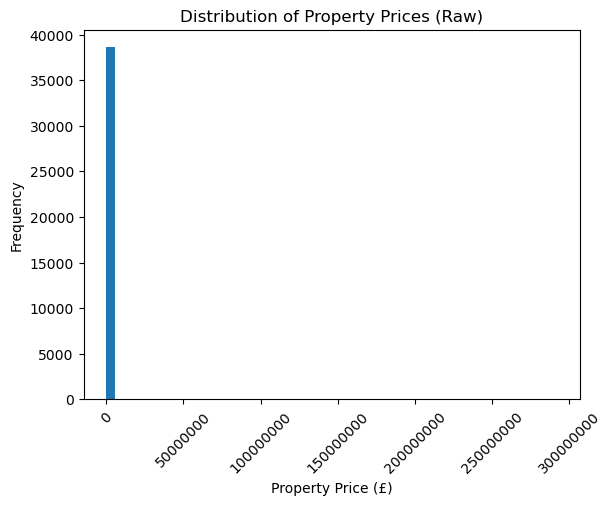

In [281]:
# Plotting the distribution of raw property prices

plt.figure()
plt.hist(df_final['price'], bins=50)
plt.ticklabel_format(style='plain', axis='x')
plt.xlabel('Property Price (£)')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.title('Distribution of Property Prices (Raw)')
plt.show()

The heavily right-skewed distribution of raw property prices above indicates that outliers exist.

In [282]:
# Checking for any property price outliers

df_final.sort_values('price', ascending=False)

,transaction_id,price,transfer_date,property_type,property_condition,duration,postcode,latitude,longitude,lsoa_code,no_school_lsoa,mean_score,imd_rank,imd_decile,distance_to_city_centre_km
16846,{E53EDD2E-ABFE-83EC-E053-6B04A8C03A59},292000000,2021-12-17,O,N,L,M3 3AQ,53.480414,-2.253286,E01033681,1,NaN,17378,6,0.635344
16255,{D707E536-74F6-0AD9-E053-6B04A8C067CC},86691213,2021-11-30,O,N,F,M1 2AR,53.474890,-2.228770,E01033654,1,NaN,16419,5,1.105018
27879,{152AB734-7891-E651-E063-4704A8C061D9},85700000,2023-06-20,O,N,F,M1 2DH,53.475105,-2.229208,E01033654,1,NaN,16419,5,1.068819
10536,{C8A3A576-F463-0425-E053-6C04A8C0947B},82000000,2021-04-09,O,N,L,M15 4RP,53.472669,-2.247440,E01033656,1,NaN,23815,8,0.736504
26693,{FAC30767-CCBF-5E20-E053-4704A8C004EE},75000000,2023-03-29,O,N,F,M3 2WY,53.481430,-2.248846,E01033658,1,NaN,13707,5,0.421787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24743,{152AB734-8383-E651-E063-4704A8C061D9},135,2022-12-05,O,N,F,M21 9FZ,53.439547,-2.287353,E01005155,0,1.0,27558,9,5.239552
2164,{BA558B33-7BFB-76EF-E053-6B04A8C0B4B7},120,2020-03-31,O,N,L,M13 0EH,53.460061,-2.218239,E01034119,0,2.0,4962,2,2.706756
28481,{0B853950-C7C4-69A5-E063-4704A8C07DAC},120,2023-07-20,O,N,F,M20 6RT,53.416954,-2.226383,E01005176,0,1.5,21315,7,6.993571
6362,{E2D14906-7542-4C2D-E053-6B04A8C0422B},115,2020-11-12,O,N,F,M40 7AE,53.490102,-2.207089,E01005132,0,2.5,2522,1,2.737974


As shown above, the property price data contains outliers that will affect the visualisation of the distribution of property prices. Therefore, the prices will need to be log-transformed to stabilise the property price data, and the log-transformed property prices will be used as the dependent variable.

In [283]:
# Log-transforming property prices

df_final.insert(loc=df_final.columns.get_loc('price') + 1, column='log_price', value=np.log(df_final['price']))

df_final

,transaction_id,price,log_price,transfer_date,property_type,property_condition,duration,postcode,latitude,longitude,lsoa_code,no_school_lsoa,mean_score,imd_rank,imd_decile,distance_to_city_centre_km
0,{9DBAD221-D663-6EB3-E053-6B04A8C0F257},561000,13.237476,2020-01-02,S,N,F,M20 2AE,53.414888,-2.235069,E01005177,1,NaN,27303,9,7.149825
1,{9DBAD221-F13F-6EB3-E053-6B04A8C0F257},168000,12.031719,2020-01-02,T,N,L,M18 8BN,53.464154,-2.184083,E01005186,0,3.333333,2463,1,4.293980
2,{9FF0D969-D7C2-11ED-E053-6C04A8C06383},945000,13.758940,2020-01-02,D,N,F,M20 3DH,53.425402,-2.227151,E01005306,1,NaN,28791,9,6.059788
3,{9FF0D969-EDA7-11ED-E053-6C04A8C06383},210000,12.254863,2020-01-02,F,N,L,M20 4PG,53.432611,-2.227008,E01005307,0,2.000000,22945,7,5.275938
4,{9DBAD221-AAD8-6EB3-E053-6B04A8C0F257},86000,11.362103,2020-01-03,T,N,F,M18 8NS,53.465688,-2.168183,E01005190,1,NaN,904,1,5.230497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38730,{2D4D7609-D68C-BDF9-E063-4804A8C0672F},147500,11.901583,2024-12-23,T,N,F,M9 5UL,53.510219,-2.212027,E01005205,0,3.000000,161,1,4.067932
38731,{2D4D7609-DC27-BDF9-E063-4804A8C0672F},300000,12.611538,2024-12-23,T,N,L,M19 3QD,53.445117,-2.189932,E01005221,0,2.000000,5092,2,5.194057
38732,{38EDC0C3-1489-0F63-E063-4704A8C00424},152000,11.931636,2024-12-23,F,N,L,M1 1EU,53.482903,-2.231134,E01034129,1,NaN,15371,5,0.957079
38733,{402A3A66-CA59-A7DF-E063-4804A8C0B80D},428716,12.968550,2024-12-23,F,Y,L,M1 5LR,53.475371,-2.249339,E01034131,1,NaN,15136,5,0.533760


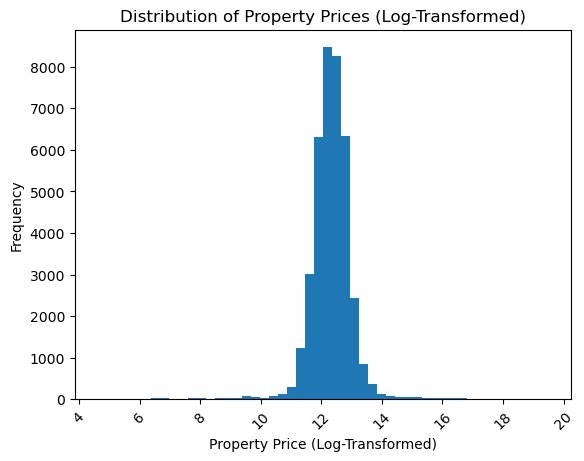

In [284]:
# Plotting the distribution of log-transformed property prices

plt.figure()
plt.hist(df_final['log_price'], bins=50)
plt.xlabel('Property Price (Log-Transformed)')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.title('Distribution of Property Prices (Log-Transformed)')
plt.show()

As displayed above, log-transforming property prices stabilises the distribution of property prices into a usable form for linear regression.

In [285]:
# Finding out how common no-school LSOAs are

df_final['no_school_lsoa'].value_counts(normalize=True)

no_school_lsoa
1    0.603795
0    0.396205
Name: proportion, dtype: float64

Around 60% of the data contains property transactions within LSOAs that have either no schools or no recent school inspections.

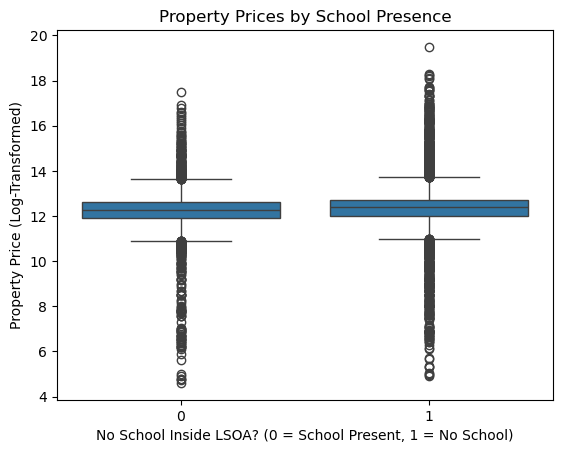

In [286]:
# Plotting property prices by whether there is a school within the LSOA

sns.boxplot(data=df_final, x='no_school_lsoa', y='log_price')
plt.xlabel('No School Inside LSOA? (0 = School Present, 1 = No School)')
plt.ylabel('Property Price (Log-Transformed)')
plt.title('Property Prices by School Presence')
plt.show()

The distribution of property prices in areas with a school differs to that of property prices in areas with no schools/inspections. This implies that the presence of schools in the area also affects property prices.

In [287]:
# Separating data containing property prices with a school in the area

df_final_with_schools = df_final[df_final['no_school_lsoa'] == 0]

df_final_with_schools

,transaction_id,price,log_price,transfer_date,property_type,property_condition,duration,postcode,latitude,longitude,lsoa_code,no_school_lsoa,mean_score,imd_rank,imd_decile,distance_to_city_centre_km
1,{9DBAD221-F13F-6EB3-E053-6B04A8C0F257},168000,12.031719,2020-01-02,T,N,L,M18 8BN,53.464154,-2.184083,E01005186,0,3.333333,2463,1,4.293980
3,{9FF0D969-EDA7-11ED-E053-6C04A8C06383},210000,12.254863,2020-01-02,F,N,L,M20 4PG,53.432611,-2.227008,E01005307,0,2.000000,22945,7,5.275938
7,{9DBAD221-AC85-6EB3-E053-6B04A8C0F257},157000,11.964001,2020-01-03,T,N,F,M14 7QB,53.449868,-2.232747,E01034127,0,2.000000,6962,3,3.320336
9,{9DBAD221-AE0D-6EB3-E053-6B04A8C0F257},255500,12.450978,2020-01-03,S,N,F,M20 2ZP,53.420298,-2.257610,E01005079,0,2.000000,14623,5,6.585753
12,{9DBAD221-D6F2-6EB3-E053-6B04A8C0F257},87000,11.373663,2020-01-03,T,N,F,M18 7HJ,53.457946,-2.163604,E01005193,0,2.000000,2082,1,5.812050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38721,{38EDC0C3-1577-0F63-E063-4704A8C00424},255000,12.449019,2024-12-20,S,N,F,M19 1LJ,53.426883,-2.208918,E01005119,0,1.500000,4136,2,6.239979
38725,{3DCCB7CA-2418-5B9D-E063-4704A8C0331E},230000,12.345835,2024-12-20,S,N,F,M23 1BB,53.399761,-2.284663,E01005117,0,4.000000,1847,1,9.210048
38726,{402A3A66-CA5A-A7DF-E063-4804A8C0B80D},285000,12.560244,2024-12-20,O,N,F,M8 8NN,53.496348,-2.240989,E01005147,0,3.500000,2034,1,1.942827
38730,{2D4D7609-D68C-BDF9-E063-4804A8C0672F},147500,11.901583,2024-12-23,T,N,F,M9 5UL,53.510219,-2.212027,E01005205,0,3.000000,161,1,4.067932


In [288]:
# Displaying the descriptive statistics for mean Ofsted scores in the LSOA of the property transaction for LSOAs with schools

df_final_with_schools['mean_score'].describe()

count    15347.000000
mean         1.939189
std          0.635477
min          1.000000
25%          1.666667
50%          2.000000
75%          2.000000
max          4.000000
Name: mean_score, dtype: float64

In [289]:
# Counting the mean Ofsted inspection scores in property transactions based in areas with a school

df_final_with_schools['mean_score'].value_counts(normalize=True)

mean_score
2.000000    0.602984
1.000000    0.182120
3.000000    0.071610
1.500000    0.045612
3.333333    0.023392
1.333333    0.018701
4.000000    0.018245
2.500000    0.015312
3.500000    0.005669
1.666667    0.005082
2.666667    0.004496
2.200000    0.003388
1.750000    0.003388
Name: proportion, dtype: float64

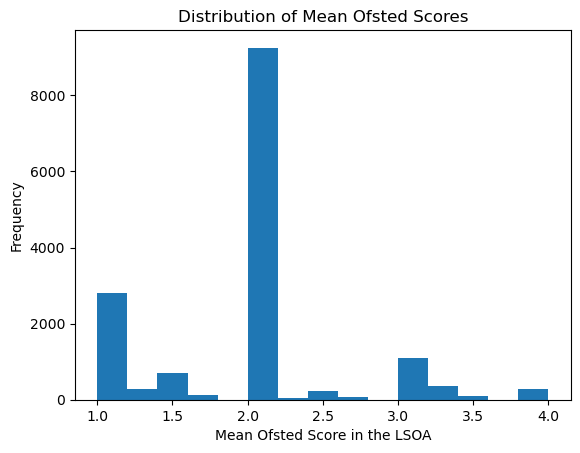

In [290]:
# Plotting the distribution of mean Ofsted scores in the LSOA of each property transaction

plt.hist(df_final_with_schools['mean_score'], bins=15)
plt.xlabel('Mean Ofsted Score in the LSOA')
plt.ylabel('Frequency')
plt.title('Distribution of Mean Ofsted Scores')
plt.show()

Based on the finding above, the majority of schools in Manchester can be considered to be generally good, with some of the smaller segments representing outstanding schools or those needing improvement.

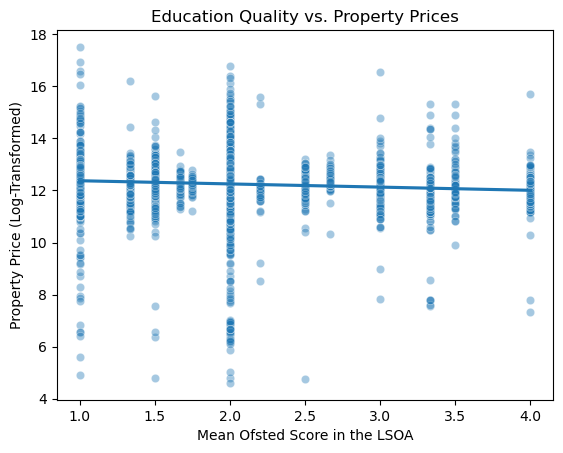

In [291]:
# Plotting the relationship between education quality and property prices in areas with schools

sns.scatterplot(data=df_final_with_schools, x='mean_score', y='log_price', alpha=0.4)
sns.regplot(data=df_final_with_schools, x='mean_score', y='log_price', scatter=False)
plt.xlabel('Mean Ofsted Score in the LSOA')
plt.ylabel('Property Price (Log-Transformed)')
plt.title('Education Quality vs. Property Prices')
plt.show()

Based on the plot above, a slightly positive but weak correlation exists between the average education quality values in the area of the property transaction and property prices, before accounting for control variables such as IMD and distance to the city centre. Additionally, even when education quality is similar, the property prices can still vary greatly. This plot indicates that education quality is one of several factors that affect property prices, and that there may be other variable driving it.

In [292]:
# Displaying the descriptive statistics for the IMD rank

df_final['imd_rank'].describe()

count    38735.000000
mean     11472.523454
std       8737.886229
min         66.000000
25%       3160.000000
50%      10775.000000
75%      18878.000000
max      32096.000000
Name: imd_rank, dtype: float64

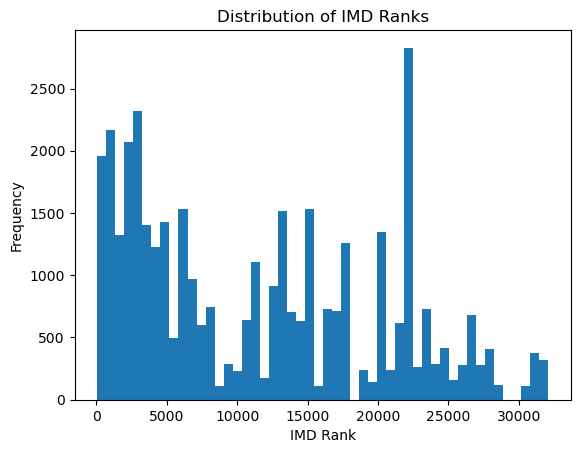

In [293]:
# Plotting the distribution of IMD ranks

plt.hist(df_final['imd_rank'], bins=50)
plt.xlabel('IMD Rank')
plt.ylabel('Frequency')
plt.title('Distribution of IMD Ranks')
plt.show()

As shown above, the IMD ranks in Manchester can vary greatly, which indicates that Manchester has diverse deprivation levels across its LSOAs.

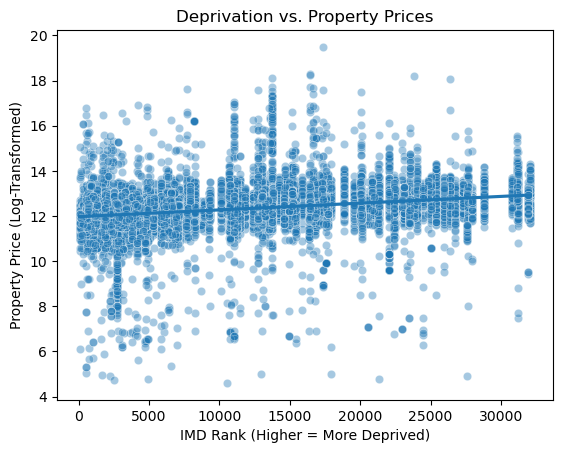

In [294]:
# Plotting the relationship between IMD ranks and property prices

sns.scatterplot(data=df_final, x='imd_rank', y='log_price', alpha=0.4)
sns.regplot(data=df_final, x='imd_rank', y='log_price', scatter=False)
plt.xlabel('IMD Rank (Higher = More Deprived)')
plt.ylabel('Property Price (Log-Transformed)')
plt.title('Deprivation vs. Property Prices')
plt.show()

The plot above shows that the relationship between IMD ranks and property prices is positive, which may be unexpected for more-deprived areas to have more expensive housing. This indicates the importance of having to account for other variables such as education quality and distance to the city centre - which are not included in this univariate analysis - to truly capture how house prices are affected by these different variables.

In [295]:
# Displaying the descriptive statistics for distance to the city centre (km)

df_final['distance_to_city_centre_km'].describe()

count    38735.000000
mean         4.306279
std          2.794073
min          0.068991
25%          1.463279
50%          4.541367
75%          5.867734
max         13.729635
Name: distance_to_city_centre_km, dtype: float64

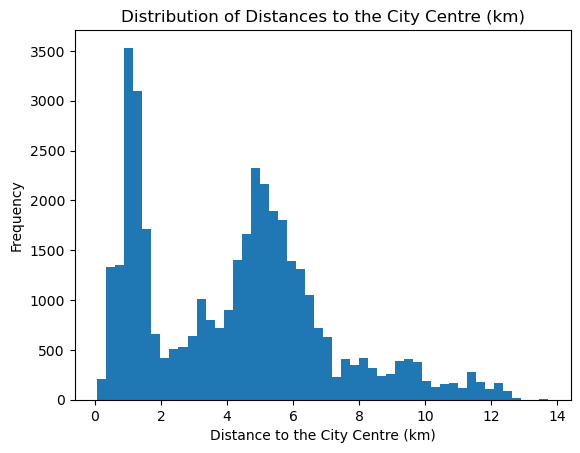

In [296]:
# Plotting the distribution of distances to the city centre (km)

plt.hist(df_final['distance_to_city_centre_km'], bins=50)
plt.xlabel('Distance to the City Centre (km)')
plt.ylabel('Frequency')
plt.title('Distribution of Distances to the City Centre (km)')
plt.show()

As shown above, the distances to the city centre from the property transaction vary, with the majority of property transactions being relatively close, reflecting the variation in how close houses in Manchester are to the city centre.

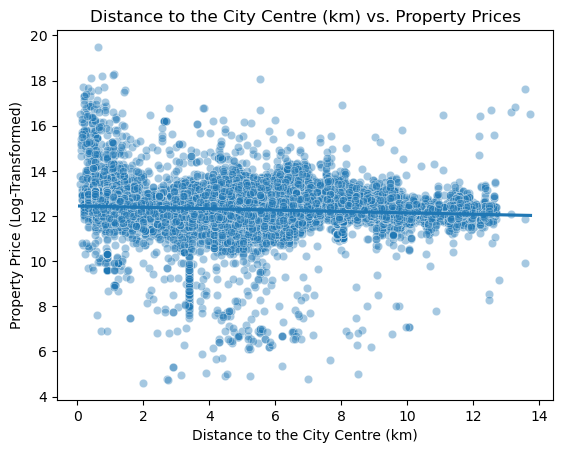

In [297]:
# Plotting the relationship between distance to the city centre (km) and property prices

sns.scatterplot(data=df_final, x='distance_to_city_centre_km', y='log_price', alpha=0.4)
sns.regplot(data=df_final, x='distance_to_city_centre_km', y='log_price', scatter=False)
plt.xlabel('Distance to the City Centre (km)')
plt.ylabel('Property Price (Log-Transformed)')
plt.title('Distance to the City Centre (km) vs. Property Prices')
plt.show()

Based on the plot above, property prices will tend to decrease as the property's distance to the city centre increases, which highlights the significance of spatial accessibility in a property's valuation.

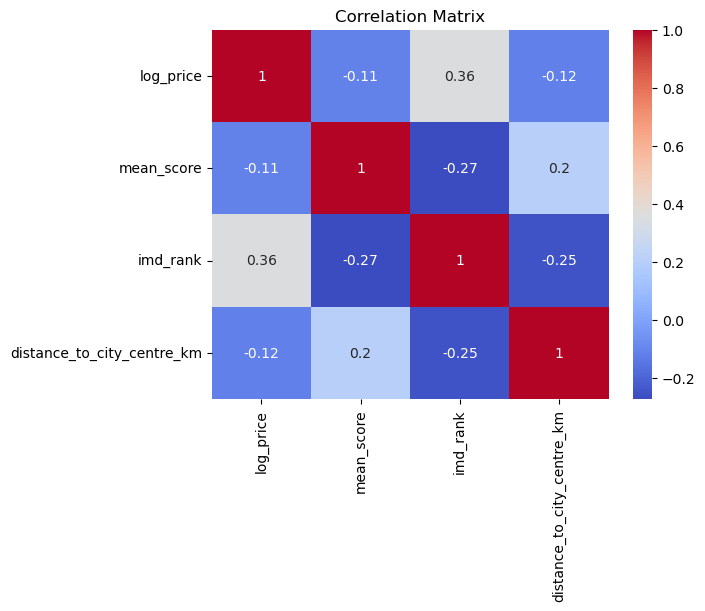

In [298]:
# Summarising correlations between different variables and property prices

correlations = df_final[['log_price', 'mean_score', 'imd_rank', 'distance_to_city_centre_km']].corr()

sns.heatmap(correlations, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

To summarise the correlations between different variables through the correlation matrix above, there is a weak positive correlation between property prices and education quality (lower score = higher quality), followed by a moderate positive correlation between property prices and IMD ranks, and a weak negative correlation between property prices and distance to the city centre. Meanwhile, education quality has a moderate negative correlation with IMD ranks and a weak positive correlation with distance to the city centre. These correlation patterns reveal that confounding exists between education quality, IMD ranks and distance to the city centre which warrants the use of multivariate regression in order to more-accurately illustrate the relationship between education qualiy and property prices in Manchester.